# Mrk 421 — STA/LTA Flare & Dip Detection (v3)
FACT nightly data, 2015–2019. Bidirectional detection (brightenings and dips).

**v3 changes:**
1. **Inverse-variance weighted** STA and LTA — handles heteroscedastic errors
   naturally, keeps all data including negative-flux non-detections.
2. Works in **linear flux space** — no log transform needed, no arbitrary
   shift constant, no SNR cut that would bias the quiescent baseline.
3. LTA still **excludes the STA window** (from v2).
4. **Gap-aware gating** retained (from v2): N_STA < 2 or gap > 60 d → NaN.
5. **Per-scale empirical thresholds** from quiescent distribution (from v2).
6. Activity table audited (from v2): Apr–May 2019 partially confirmed
   (ATel #12683), Dec 2017 window extended to Apr 2018.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(
    "../../data/FACT_preliminary_421_20min_150101_191231_katha.dat",
    sep="\t",
    skiprows=4,
    names=[
        "MJDstart", "MJDstop",
        "flux_ph_cm2_s", "flux_err_ph_cm2_s",
        "flux_CU", "flux_err_CU",
        "ontime",
        "flag1", "flag2", "flag3", "flag4",
    ]
)

# ── Clean: drop non-numeric header row ───────────────────────────────────────
mask_bad = pd.to_numeric(df["flux_ph_cm2_s"], errors="coerce").isna()
df = df[~mask_bad].copy()
for col in ["MJDstart", "MJDstop", "flux_ph_cm2_s", "flux_err_ph_cm2_s",
            "flux_CU", "flux_err_CU"]:
    df[col] = pd.to_numeric(df[col])

# ── Time axis ────────────────────────────────────────────────────────────────
df["MJD"] = (df["MJDstart"] + df["MJDstop"]) / 2
df["Fecha"] = pd.to_datetime(df["MJD"] - 40587.0, unit="D")
df.set_index("Fecha", inplace=True)
df.sort_index(inplace=True)

# ── Inverse-variance weights ────────────────────────────────────────────────
# w_i = 1 / σ_i².  No log transform, no SNR cut — all points kept.
df["w"] = 1.0 / df["flux_err_ph_cm2_s"] ** 2

print(f"Observations loaded: {len(df)}")
print(f"Coverage: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Negative-flux points: {(df['flux_ph_cm2_s'] < 0).sum()}")
print(f"SNR < 1 points: {(df['flux_ph_cm2_s'].abs() / df['flux_err_ph_cm2_s'] < 1).sum()}")


Observations loaded: 5109
Coverage: 2015-01-15 → 2019-06-27
Negative-flux points: 586
SNR < 1 points: 1503


In [3]:
def weighted_median(values, weights):
    """Compute the weighted median of an array.

    The weighted median is the value m that minimises Σ w_i |x_i − m|,
    or equivalently the value where the cumulative weight reaches 50%.

    Args:
        values (np.ndarray): Data values.
        weights (np.ndarray): Positive weights (e.g. 1/σ²).

    Returns:
        float: Weighted median, or NaN if inputs are empty.
    """
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    v = values[mask]
    w = weights[mask]
    if len(v) == 0:
        return np.nan
    order = np.argsort(v)
    v, w = v[order], w[order]
    cumw = np.cumsum(w)
    half = cumw[-1] / 2.0
    idx = np.searchsorted(cumw, half)
    return v[min(idx, len(v) - 1)]


def weighted_mad(values, weights, median_val):
    """Compute the weighted MAD (median absolute deviation).

    Args:
        values (np.ndarray): Data values.
        weights (np.ndarray): Positive weights.
        median_val (float): Pre-computed weighted median.

    Returns:
        float: MAD scaled to σ-equivalent (× 1.4826).
    """
    abs_dev = np.abs(values - median_val)
    raw_mad = weighted_median(abs_dev, weights)
    return 1.4826 * raw_mad


def compute_sta_lta_zscore(df, sta_window, lta_window,
                           min_lta_obs=5, min_sta_obs=2,
                           max_gap_days=60):
    """Compute an inverse-variance weighted STA/LTA Z-score per observation.

    Works in linear flux space with per-observation weights w_i = 1/σ_i²,
    so noisy nights (including negative-flux non-detections) are naturally
    downweighted rather than discarded.

    The STA is a weighted mean; the LTA baseline is a weighted median
    (robust to flare contamination); the intrinsic scatter is estimated
    via weighted MAD over the LTA-only window.

    The LTA window excludes the STA window to prevent self-contamination.

    Supports both day-scale (e.g. ``'3D'``, ``'21D'``) and hour-scale
    (e.g. ``'1h'``, ``'4h'``) windows via ``pd.Timedelta`` parsing.

    Args:
        df (pd.DataFrame): DataFrame with DatetimeIndex and columns
            ``flux_ph_cm2_s``, ``flux_err_ph_cm2_s``, ``w``, ``MJD``.
        sta_window (str): Short-window size, e.g. ``'3D'`` or ``'1h'``.
        lta_window (str): Long-window size, e.g. ``'21D'`` or ``'4h'``.
        min_lta_obs (int): Minimum observations in the LTA-only window.
            Fewer → NaN.  Default 5.
        min_sta_obs (int): Minimum observations in the STA window.
            Fewer → NaN.  Default 2.
        max_gap_days (float): Maximum gap (days) between the current
            observation and the newest LTA-only observation.  Default 60.

    Returns:
        pd.DataFrame: Copy of input with columns ``Z_score``, ``Z_valid``,
            ``N_STA``, ``N_LTA_only``, ``STA_wmean``, ``LTA_wmedian``,
            ``sigma_sta``, ``sigma_intrinsic``, ``sigma_total``,
            ``gap_to_LTA_days``.
    """
    out = df.copy()
    flux = out["flux_ph_cm2_s"].values
    err  = out["flux_err_ph_cm2_s"].values
    w    = out["w"].values
    dates = out.index

    sta_td = pd.Timedelta(sta_window)
    lta_td = pd.Timedelta(lta_window)

    n_obs = len(out)
    N_STA          = np.full(n_obs, np.nan)
    N_LTA_only     = np.full(n_obs, np.nan)
    STA_wmean      = np.full(n_obs, np.nan)
    sigma_sta      = np.full(n_obs, np.nan)
    LTA_wmedian    = np.full(n_obs, np.nan)
    sigma_intr     = np.full(n_obs, np.nan)
    gap_days       = np.full(n_obs, np.nan)

    for i in range(n_obs):
        t_i = dates[i]

        # ── STA window: [t - sta_td, t] ─────────────────────────────────
        t_sta_start = t_i - sta_td
        sta_mask = (dates >= t_sta_start) & (dates <= t_i)
        f_sta = flux[sta_mask]
        w_sta = w[sta_mask]
        n_sta = np.sum(np.isfinite(f_sta))
        N_STA[i] = n_sta

        if n_sta >= 1:
            # Weighted mean: Σ(w_i f_i) / Σ(w_i)
            sum_w = np.nansum(w_sta)
            STA_wmean[i] = np.nansum(w_sta * f_sta) / sum_w
            # Uncertainty on weighted mean: 1 / sqrt(Σ w_i)
            sigma_sta[i] = 1.0 / np.sqrt(sum_w)

        # ── LTA-only window: [t - lta_td, t - sta_td) ──────────────────
        t_lta_start = t_i - lta_td
        lta_mask = (dates >= t_lta_start) & (dates < t_sta_start)
        f_lta = flux[lta_mask]
        w_lta = w[lta_mask]
        n_lta = np.sum(np.isfinite(f_lta))
        N_LTA_only[i] = n_lta

        if n_lta < min_lta_obs:
            continue

        # Gap to newest LTA point
        lta_dates = dates[lta_mask]
        gap_days[i] = (t_i - lta_dates[-1]).total_seconds() / 86400.0

        # Weighted median (robust to flare contamination)
        wmed = weighted_median(f_lta, w_lta)
        LTA_wmedian[i] = wmed

        # Weighted MAD → intrinsic scatter
        sigma_intr[i] = weighted_mad(f_lta, w_lta, wmed)

    out["N_STA"]          = N_STA
    out["N_LTA_only"]     = N_LTA_only
    out["STA_wmean"]      = STA_wmean
    out["sigma_sta"]      = sigma_sta
    out["LTA_wmedian"]    = LTA_wmedian
    out["sigma_intrinsic"] = sigma_intr
    out["gap_to_LTA_days"] = gap_days

    # ── Total denominator ────────────────────────────────────────────────
    out["sigma_total"] = np.sqrt(out["sigma_sta"] ** 2
                                 + out["sigma_intrinsic"] ** 2)

    # ── Z-score ──────────────────────────────────────────────────────────
    out["Z_score"] = (out["STA_wmean"] - out["LTA_wmedian"]) / (
        out["sigma_total"] + 1e-30
    )

    # ── Gap-aware gating ─────────────────────────────────────────────────
    stale  = out["gap_to_LTA_days"] > max_gap_days
    sparse = out["N_STA"] < min_sta_obs
    out["Z_valid"] = (~stale & ~sparse
                      & out["Z_score"].notna()
                      & np.isfinite(out["Z_score"]))
    out.loc[~out["Z_valid"], "Z_score"] = np.nan

    return out

In [4]:
SCALES = [
    ("1h",  "4h",   "Intra-night (1h / 4h)"),
    ("4h",  "2D",   "Night-to-night (4h / 2d)"),
    ("1D",  "7D",   "Multi-day (1d / 7d)"),
    ("3D",  "21D",  "Weekly (3d / 21d)"),
]

# ── Quiescent period for empirical threshold calibration ─────────────────────
QUIESCENT_START = "2015-01-01"
QUIESCENT_END   = "2016-07-01"
QUANTILE        = 0.995

results    = {}
thresholds = {}

for sta_w, lta_w, label in SCALES:
    res = compute_sta_lta_zscore(df, sta_w, lta_w)
    results[label] = res

    # Empirical threshold from quiescent Z-distribution
    mask_q = (res.index >= QUIESCENT_START) & (res.index <= QUIESCENT_END)
    z_q = res.loc[mask_q, "Z_score"].dropna()
    thr = z_q.quantile(QUANTILE)
    thresholds[label] = round(thr, 2)

    n_valid  = res["Z_valid"].sum()
    n_bright = (res["Z_score"] >=  thr).sum()
    n_dip    = (res["Z_score"] <= -thr).sum()
    n_gated  = (~res["Z_valid"]).sum()
    print(f"{label:25s}  threshold={thr:5.2f}σ  "
          f"bright={n_bright:3d}  dips={n_dip:3d}  "
          f"gated_out={n_gated:3d}/{len(res)}")

print(f"\nQuiescent period: {QUIESCENT_START} → {QUIESCENT_END}")
print(f"Quantile used: {QUANTILE}")


Intra-night (1h / 4h)      threshold= 2.78σ  bright= 10  dips=  5  gated_out=3312/5109
Night-to-night (4h / 2d)   threshold= 5.44σ  bright= 10  dips=  0  gated_out=1412/5109
Multi-day (1d / 7d)        threshold= 2.90σ  bright= 88  dips=  3  gated_out=517/5109
Weekly (3d / 21d)          threshold= 2.86σ  bright= 55  dips=  8  gated_out=203/5109

Quiescent period: 2015-01-01 → 2016-07-01
Quantile used: 0.995


In [5]:
# ── Calibration diagnostics ───────────────────────────────────────────────────
print(f"Quiescent period: {QUIESCENT_START} → {QUIESCENT_END}")
print(f"Quantile: {QUANTILE} (empirical per-scale)\n")
print(f"{'Scale':25s}  {'Threshold':>10s}  {'N_quiesc':>10s}  "
      f"{'p99.7':>8s}  {'p99.5':>8s}  {'p99.0':>8s}  {'p50':>8s}")
print("-" * 85)
for sta_w, lta_w, label in SCALES:
    res  = results[label]
    mask = (res.index >= QUIESCENT_START) & (res.index <= QUIESCENT_END)
    z_q  = res.loc[mask, "Z_score"].dropna()
    print(f"{label:25s}  {thresholds[label]:>10.2f}  {len(z_q):>10d}  "
          f"{z_q.quantile(0.997):>8.2f}  {z_q.quantile(0.995):>8.2f}  "
          f"{z_q.quantile(0.990):>8.2f}  {z_q.quantile(0.500):>8.2f}")


Quiescent period: 2015-01-01 → 2016-07-01
Quantile: 0.995 (empirical per-scale)

Scale                       Threshold    N_quiesc     p99.7     p99.5     p99.0       p50
-------------------------------------------------------------------------------------
Intra-night (1h / 4h)            2.78         630      2.98      2.78      2.59      0.10
Night-to-night (4h / 2d)         5.44        1305      5.85      5.44      3.89      0.04
Multi-day (1d / 7d)              2.90        1628      3.06      2.90      2.55      0.03
Weekly (3d / 21d)                2.86        1760      2.90      2.86      2.78      0.09


In [6]:
# ── Denominator diagnostics ───────────────────────────────────────────────────
# Verify that sigma_total is dominated by intrinsic scatter, not measurement noise.
print(f"{'Scale':25s}  {'med(σ_sta)':>12s}  {'med(σ_intr)':>12s}  "
      f"{'ratio intr/sta':>16s}")
print("-" * 70)
for sta_w, lta_w, label in SCALES:
    res = results[label]
    valid = res[res["Z_valid"]]
    s_sta  = valid["sigma_sta"].median()
    s_intr = valid["sigma_intrinsic"].median()
    print(f"{label:25s}  {s_sta:>12.2e}  {s_intr:>12.2e}  "
          f"{s_intr/s_sta:>16.1f}×")


Scale                        med(σ_sta)   med(σ_intr)    ratio intr/sta
----------------------------------------------------------------------
Intra-night (1h / 4h)          5.99e-12      8.75e-12               1.5×
Night-to-night (4h / 2d)       4.50e-12      1.04e-11               2.3×
Multi-day (1d / 7d)            3.24e-12      1.17e-11               3.6×
Weekly (3d / 21d)              2.06e-12      1.30e-11               6.3×


/var/folders/74/0zssb6h97glb_0klc2951pqc0000gn/T/ipykernel_35700/3609129973.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(start, end, color=col, alpha=0.14,
/var/folders/74/0zssb6h97glb_0klc2951pqc0000gn/T/ipykernel_35700/3609129973.py:52: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(start, end, color=col, alpha=0.10,


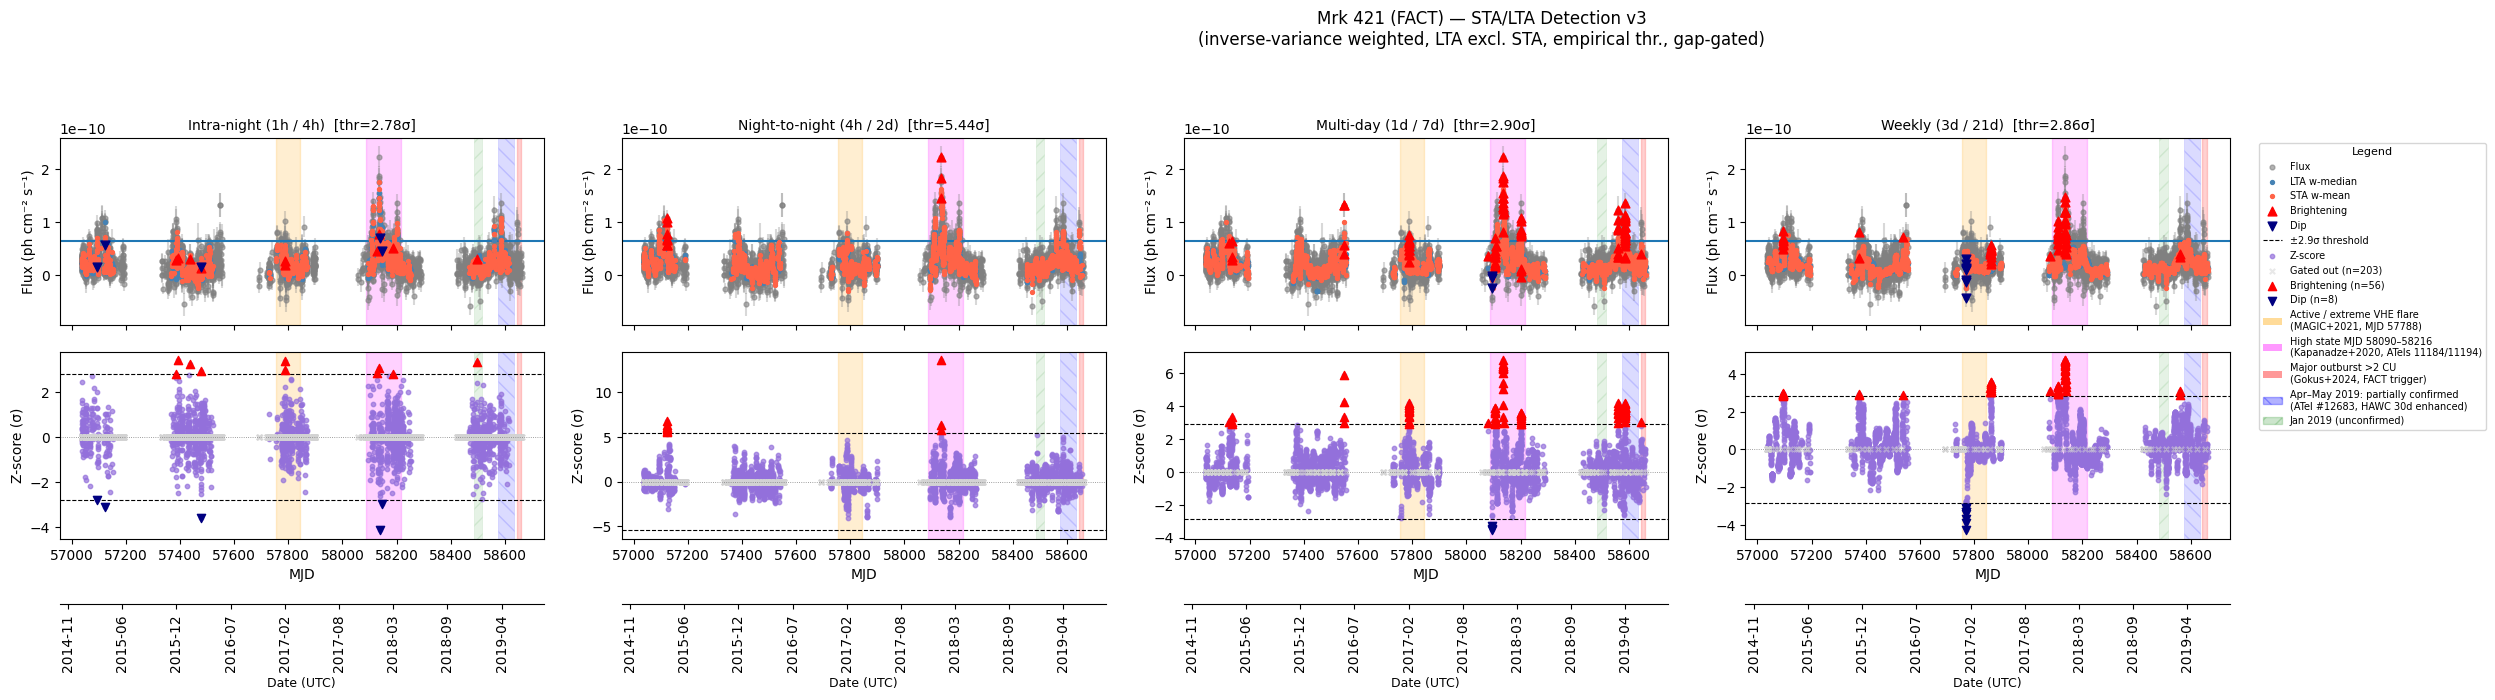


Scale                       Thr (σ)    Bright    Dips    Gated    Valid
--------------------------------------------------------------------
Intra-night (1h / 4h)          2.78        10       5     3312     1797
Night-to-night (4h / 2d)       5.44        10       0     1412     3697
Multi-day (1d / 7d)            2.90        87       3      517     4592
Weekly (3d / 21d)              2.86        56       8      203     4906


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# ── Shaded regions ───────────────────────────────────────────────────────────
t_regions_confirmed = [
    (Time("2017-01-01").mjd, Time("2017-03-31").mjd,
     "orange", "Active / extreme VHE flare\n(MAGIC+2021, MJD 57788)"),
    (Time("2017-12-01").mjd, Time("2018-04-08").mjd,
     "magenta", "High state MJD 58090–58216\n(Kapanadze+2020, ATels 11184/11194)"),
    (Time("2019-06-09").mjd, Time("2019-06-25").mjd,
     "red", "Major outburst >2 CU\n(Gokus+2024, FACT trigger)"),
]

t_regions_partial = [
    (Time("2019-04-01").mjd, Time("2019-05-31").mjd,
     "blue", "Apr–May 2019: partially confirmed\n(ATel #12683, HAWC 30d enhanced)"),
]

t_regions_unconfirmed = [
    (Time("2019-01-01").mjd, Time("2019-01-31").mjd,
     "green", "Jan 2019 (unconfirmed)"),
]

fig, axes = plt.subplots(
    nrows=2, ncols=len(SCALES),
    figsize=(6 * len(SCALES) + 6, 8),
    sharex=True
)

if len(SCALES) == 1:
    axes = axes.reshape(2, 1)

for col_idx, (sta_w, lta_w, label) in enumerate(SCALES):
    res = results[label]
    thr = thresholds[label]
    bright = res[res["Z_score"] >=  thr].copy()
    dip    = res[res["Z_score"] <= -thr].copy()

    ax_lc = axes[0, col_idx]
    ax_z  = axes[1, col_idx]

    for ax in [ax_lc, ax_z]:
        for start, end, col, _ in t_regions_confirmed:
            ax.axvspan(start, end, color=col, alpha=0.18, zorder=0)
        for start, end, col, _ in t_regions_partial:
            ax.axvspan(start, end, color=col, alpha=0.14,
                       hatch="\\\\", edgecolor=col, linewidth=0.5, zorder=0)
        for start, end, col, _ in t_regions_unconfirmed:
            ax.axvspan(start, end, color=col, alpha=0.10,
                       hatch="//", edgecolor=col, linewidth=0.5, zorder=0)

    # ── Light curve panel ─────────────────────────────────────────────────
    ax_lc.errorbar(res["MJD"], res["flux_ph_cm2_s"],
                   yerr=res["flux_err_ph_cm2_s"],
                   fmt="none", ecolor="gray", alpha=0.3, zorder=1)
    ax_lc.scatter(res["MJD"], res["flux_ph_cm2_s"],
                  color="gray", alpha=0.6, s=12, label="Flux", zorder=2)

    # Plot weighted LTA and STA
    valid = res[res["Z_valid"]]
    ax_lc.scatter(valid["MJD"], valid["LTA_wmedian"],
                  color="steelblue", s=8, label="LTA w-median", zorder=3)
    ax_lc.scatter(valid["MJD"], valid["STA_wmean"],
                  color="tomato", s=8, label="STA w-mean", zorder=4)
    
    ax_lc.axhline(6.45e-11)

    if not bright.empty:
        ax_lc.scatter(bright["MJD"], bright["flux_ph_cm2_s"],
                      color="red", s=40, marker="^", zorder=5,
                      label="Brightening")
    if not dip.empty:
        ax_lc.scatter(dip["MJD"], dip["flux_ph_cm2_s"],
                      color="navy", s=40, marker="v", zorder=5, label="Dip")
    ax_lc.set_ylabel("Flux (ph cm⁻² s⁻¹)")
    ax_lc.set_title(f"{label}  [thr={thr:.2f}σ]", fontsize=10)

    # ── Z-score panel ─────────────────────────────────────────────────────
    ax_z.axhline( thr, color="black", linestyle="--", linewidth=0.8,
                 label=f"±{thr:.1f}σ threshold")
    ax_z.axhline(-thr, color="black", linestyle="--", linewidth=0.8)
    ax_z.axhline(0, color="gray", linestyle=":", linewidth=0.6)

    v_pts = res[res["Z_valid"]]
    g_pts = res[~res["Z_valid"]]
    ax_z.scatter(v_pts["MJD"], v_pts["Z_score"],
                 color="mediumpurple", s=10, alpha=0.7, label="Z-score")
    if not g_pts.empty:
        ax_z.scatter(g_pts["MJD"], [0]*len(g_pts),
                     color="lightgray", s=15, marker="x", alpha=0.5,
                     label=f"Gated out (n={len(g_pts)})")

    if not bright.empty:
        ax_z.scatter(bright["MJD"], bright["Z_score"],
                     color="red", s=35, marker="^", zorder=5,
                     label=f"Brightening (n={len(bright)})")
    if not dip.empty:
        ax_z.scatter(dip["MJD"], dip["Z_score"],
                     color="navy", s=35, marker="v", zorder=5,
                     label=f"Dip (n={len(dip)})")
    ax_z.set_xlabel("MJD")
    ax_z.set_ylabel("Z-score (σ)")

    # ── Secondary date axis ───────────────────────────────────────────────
    def mjd_to_date(mjd_val):
        """Convert MJD to matplotlib date number."""
        mjd_val = np.asanyarray(mjd_val)
        if mjd_val.size == 0:
            return mjd_val
        return mdates.date2num(Time(mjd_val, format="mjd").to_datetime())

    def date_to_mjd(date_num):
        """Convert matplotlib date number to MJD."""
        date_num = np.asanyarray(date_num)
        if date_num.size == 0:
            return date_num
        return Time(mdates.num2date(date_num)).mjd

    secax = ax_z.secondary_xaxis(
        -0.35, functions=(mjd_to_date, date_to_mjd)
    )
    secax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    secax.set_xlabel("Date (UTC)", fontsize=9)
    plt.setp(secax.get_xticklabels(), rotation=90, ha="center")

# ── Global legend ─────────────────────────────────────────────────────────────
handles, labels_h = axes[0, -1].get_legend_handles_labels()
z_h, z_l = axes[1, -1].get_legend_handles_labels()
combined = dict(zip(labels_h + z_l, handles + z_h))

for start, end, col, lab in t_regions_confirmed:
    combined[lab] = Patch(facecolor=col, alpha=0.4, label=lab)
for start, end, col, lab in t_regions_partial:
    combined[lab] = Patch(facecolor=col, alpha=0.3,
                          hatch="\\\\", edgecolor=col, label=lab)
for start, end, col, lab in t_regions_unconfirmed:
    combined[lab] = Patch(facecolor=col, alpha=0.2,
                          hatch="//", edgecolor=col, label=lab)

axes[0, -1].legend(
    combined.values(), combined.keys(),
    loc="upper left", bbox_to_anchor=(1.05, 1),
    fontsize=7, frameon=True, title="Legend", title_fontsize=8
)

plt.suptitle(
    "Mrk 421 (FACT) — STA/LTA Detection v3\n"
    "(inverse-variance weighted, LTA excl. STA, empirical thr., gap-gated)",
    fontsize=12, y=0.99
)
plt.tight_layout(rect=(0, 0.08, 0.84, 0.94))
plt.show()

# ── Detection summary ─────────────────────────────────────────────────────────
print(f"\n{'Scale':25s}  {'Thr (σ)':>8s}  {'Bright':>8s}  {'Dips':>6s}  "
      f"{'Gated':>7s}  {'Valid':>7s}")
print("-" * 68)
for sta_w, lta_w, label in SCALES:
    res = results[label]
    thr = thresholds[label]
    b = (res["Z_score"] >=  thr).sum()
    d = (res["Z_score"] <= -thr).sum()
    g = (~res["Z_valid"]).sum()
    v = res["Z_valid"].sum()
    print(f"{label:25s}  {thr:>8.2f}  {b:>8d}  {d:>6d}  {g:>7d}  {v:>7d}")


## Activity Table (v3 — audited)

| Date(s)                    | Activity Level                        | Instruments                  | Notes                                                                                      | Status                |
|:---------------------------|:--------------------------------------|:-----------------------------|:-------------------------------------------------------------------------------------------|:----------------------|
| Jan – Mar 2017             | Active period incl. extreme VHE flare | FACT, MAGIC, NuSTAR          | MJD 57788 (Feb 4): factor-10 TeV increase, orphan-like, two-zone leptonic model required (MAGIC+2021) | Confirmed             |
| Dec 2017 – Apr 2018        | High state / exceptional TeV flare    | Swift XRT/BAT, FACT, HAWC, TACTIC | MJD 58090–58216; ATels #11184 (FACT exceptional flare), #11194 (HAWC month-long peak), #11195 (Swift/BAT correlated hard X-ray); Kapanadze+2020 | Confirmed             |
| Jan 2019                   | Unknown                               | —                            | No ATel or peer-reviewed reference found; may be post-seasonal-gap artifact. Needs MWL cross-check | Unconfirmed           |
| Apr – May 2019             | Enhanced TeV activity (~30 d)         | HAWC, (FACT)                 | ATel #12683 (HAWC, 23 Apr 2019): enhanced activity for >30 days. Overlaps STA/LTA detection window | Partially confirmed   |
| Jun 9–25, 2019             | Major outburst                        | FACT (trigger), XMM-Newton   | >2 CU on Jun 9; brightest XMM-Newton state ever recorded; Gokus+2024 (MNRAS 529, 1450)    | Confirmed             |

## Changelog

### v2 → v3
| # | Fix | Rationale |
|---|-----|-----------|
| 1 | Inverse-variance weighted STA (weighted mean) and LTA (weighted median) | Handles heteroscedastic errors naturally. A night with σ = 2.5×10⁻¹¹ (essentially unmeasured) gets weight ~1600× lower than a clean σ = 2×10⁻¹² night. No data discarded — negative-flux non-detections are kept and properly downweighted. |
| 2 | Linear flux space (no log transform) | Avoids pathological behaviour of log(flux) and σ/f for negative or near-zero flux values. With proper weighting, the distributional symmetry argument for log-space is no longer needed. |
| 3 | Weighted MAD for intrinsic scatter | The LTA scatter estimate now respects measurement quality. Noisy nights don't inflate the denominator and mask real flares. |

### v1 → v2
| # | Fix | Rationale |
|---|-----|-----------|
| 1 | LTA excludes STA window | Prevents flare self-contamination of the background estimate. |
| 2 | Per-scale empirical thresholds | Removes Gaussian assumption; each scale's threshold set by its own quiescent tail. |
| 3 | Gap-aware gating (N_STA < 2, gap > 60d → NaN) | Prevents spurious triggers at seasonal gap boundaries. |
| 4 | Apr–May 2019 → Partially confirmed | ATel #12683 (HAWC) independently confirms enhanced TeV activity. |
| 5 | Dec 2017 window → Apr 2018 | Consistent with Kapanadze+2020 and ATels #11184/#11194/#11195. |

In [8]:
res = results["Intra-night (1h / 4h)"]
bright = res[res["Z_score"] >= thresholds["Intra-night (1h / 4h)"]]
print(bright[["MJD", "flux_ph_cm2_s", "flux_err_ph_cm2_s", "Z_score", 
              "N_STA", "N_LTA_only", "STA_wmean", "LTA_wmedian"]].to_string())

                                       MJD  flux_ph_cm2_s  flux_err_ph_cm2_s   Z_score  N_STA  N_LTA_only     STA_wmean   LTA_wmedian
Fecha                                                                                                                                
2015-12-29 05:53:31.200000388  57385.24550   2.879990e-11       2.149990e-11  2.789336    3.0         6.0  4.124582e-11 -8.300000e-12
2016-01-05 04:40:30.719999784  57392.19480   3.240000e-11       1.070000e-11  3.412018    3.0         5.0  3.301444e-11  2.500000e-12
2016-02-18 02:03:46.080000051  57436.08595   3.029990e-11       1.729990e-11  3.255352    3.0         6.0  3.732144e-11 -3.300000e-12
2016-03-29 02:12:33.119999939  57476.09205   1.320000e-11       1.669990e-11  2.942073    3.0         8.0  3.114427e-11  7.000000e-13
2017-02-03 03:51:11.520000043  57787.16055   1.850000e-11       8.700000e-12  3.385522    3.0         7.0  2.192709e-11  3.900000e-12
2017-02-03 04:12:56.160000406  57787.17565   2.690000e-11     

In [9]:
dip = res[res["Z_score"] <= -thresholds["Intra-night (1h / 4h)"]]
print(dip[["MJD", "flux_ph_cm2_s", "flux_err_ph_cm2_s", "Z_score", 
           "N_STA", "N_LTA_only", "STA_wmean", "LTA_wmedian"]].to_string())

                                       MJD  flux_ph_cm2_s  flux_err_ph_cm2_s   Z_score  N_STA  N_LTA_only     STA_wmean   LTA_wmedian
Fecha                                                                                                                                
2015-03-12 03:12:05.760000527  57093.13340   1.590000e-11       1.489990e-11 -2.802242    3.0         6.0  2.865005e-11  5.920000e-11
2015-04-12 00:49:01.920000172  57124.03405   5.599990e-11       1.229990e-11 -3.109867    3.0         5.0  6.240385e-11  1.009000e-10
2016-03-30 01:18:41.760000475  57477.05465   1.460000e-11       1.020000e-11 -3.604244    3.0         9.0 -7.034530e-12  1.360000e-11
2018-01-19 04:54:02.880000008  58137.20420   6.960000e-11       1.249990e-11 -4.116747    3.0         7.0  8.672249e-11  1.197000e-10
2018-01-27 05:13:50.880000492  58145.21795   4.550000e-11       1.139990e-11 -2.950218    3.0         8.0  4.824643e-11  7.950000e-11


Index(['MJDstart', 'MJDstop', 'flux_ph_cm2_s', 'flux_err_ph_cm2_s', 'flux_CU',
       'flux_err_CU', 'ontime', 'flag1', 'flag2', 'flag3', 'flag4', 'MJD',
       'w'],
      dtype='str')

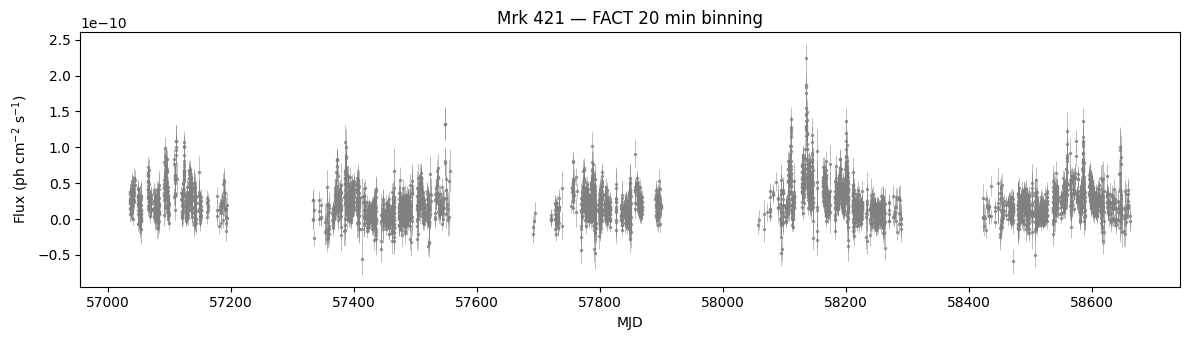

In [12]:
fig, ax = plt.subplots(figsize=(12, 3.5))
mjd = (df["MJDstart"] + df["MJDstop"]) / 2
ax.errorbar(mjd, df["flux_ph_cm2_s"], yerr=df["flux_err_ph_cm2_s"],
            fmt=".", ms=3, elinewidth=0.5, color="gray", alpha=0.7)
ax.set_xlabel("MJD")
ax.set_ylabel("Flux (ph cm$^{-2}$ s$^{-1}$)")
ax.set_title("Mrk 421 — FACT 20 min binning")
plt.tight_layout()
plt.savefig("fig_lightcurve.png", dpi=200)
plt.show()